##Imports:

In [48]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/shishir/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##Load Dataset:

In [2]:
# Load dataset directly from local disk (No token or network required)
train_set = load_dataset("parquet", data_files={"train": "data/wildguardtrain.parquet"})
test_set = load_dataset("parquet", data_files={"test": "data/wildguardtest.parquet"})


In [3]:
train_df = train_set['train'].to_pandas()
test_df = test_set['test'].to_pandas()


LABEL_MAP = {
    ("unharmful", False): 0,
    ("unharmful", True): 1,
    ("harmful", False): 2,
    ("harmful", True): 3,
}

TARGET_NAMES = {
    0: "Benign_Vanilla",
    1: "Benign_Adversarial",
    2: "Harmful_Vanilla",
    3: "Harmful_Adversarial",
}

def safe_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}

def process_target_labels(df):
    before = len(df)

    # Drop rows missing required label columns
    df_clean = df.dropna(subset=['prompt_harm_label', 'adversarial']).copy()

    # Create 4-class target
    df_clean['target'] = [
        LABEL_MAP.get((str(harm).strip().lower(), safe_bool(adv)))
        for harm, adv in zip(
            df_clean['prompt_harm_label'],
            df_clean['adversarial']
        )
    ]

    # Remove rows where mapping failed
    df_clean = df_clean.dropna(subset=['target'])

    # Convert target to int
    df_clean['target'] = df_clean['target'].astype(int)

    # Add readable class name
    df_clean['target_name'] = df_clean['target'].map(TARGET_NAMES)

    print(f"Rows kept: {len(df_clean)}/{before}")

    # Keep only required columns
    return df_clean[['prompt', 'target', 'target_name']]

train_df = process_target_labels(train_df)
test_df = process_target_labels(test_df)

print(train_df['target_name'].value_counts())
print(test_df['target_name'].value_counts())

Rows kept: 86759/86759
Rows kept: 1699/1725
target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


#EDA:


In [4]:
print("Train Shape: ", train_df.shape)
print("Test Shape: ", test_df.shape)

print("Train Columns: ", train_df.columns.tolist())
print("Test Columns: ", test_df.columns.tolist())

Train Shape:  (86759, 3)
Test Shape:  (1699, 3)
Train Columns:  ['prompt', 'target', 'target_name']
Test Columns:  ['prompt', 'target', 'target_name']


In [5]:
print("Train Data:")
train_df.info()

print("\n" + "=" * 30)

print("Test Data:")
test_df.info()

Train Data:
<class 'pandas.DataFrame'>
RangeIndex: 86759 entries, 0 to 86758
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       86759 non-null  str  
 1   target       86759 non-null  int64
 2   target_name  86759 non-null  str  
dtypes: int64(1), str(2)
memory usage: 44.8 MB

Test Data:
<class 'pandas.DataFrame'>
Index: 1699 entries, 0 to 1724
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       1699 non-null   str  
 1   target       1699 non-null   int64
 2   target_name  1699 non-null   str  
dtypes: int64(1), str(2)
memory usage: 877.1 KB


In [6]:
#Missing Values in train and test data
print(train_df.isnull().sum())

print("\n" + "=" * 30)

print(test_df.isnull().sum())

prompt         0
target         0
target_name    0
dtype: int64

prompt         0
target         0
target_name    0
dtype: int64


In [7]:
#Empty prompts in train and test data
train_empty = train_df[train_df['prompt'].str.strip() == '']
print("Empty prompts in train data: ", train_empty.shape[0])

test_empty = test_df[test_df['prompt'].str.strip() == '']
print("Empty prompts in test data: ", test_empty.shape[0])

Empty prompts in train data:  14
Empty prompts in test data:  0


In [8]:
#Short prompts in train and test data
print("Short prompts in train data: ")
display(train_df[['prompt', 'target_name']].assign(word_count=train_df['prompt'].str.split().str.len()).sort_values("word_count").head(20))

Short prompts in train data: 


,prompt,target_name,word_count
10693,,Benign_Vanilla,0
20839,,Benign_Adversarial,0
37898,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
37891,,Benign_Vanilla,0
38037,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38081,,Benign_Vanilla,0
38282,,Benign_Vanilla,0
10346,,Benign_Vanilla,0


In [9]:
#Duplicate prompts in train and test data
print("Duplicate prompts in train data: ", 
      train_df["prompt"].duplicated().sum())


print("Duplicate prompts in test data: ", 
      test_df["prompt"].duplicated().sum())

Duplicate prompts in train data:  38907
Duplicate prompts in test data:  0


In [10]:
#Class distribution in train and test data
train_class_counts = train_df['target_name'].value_counts()
print(train_class_counts)

test_class_counts = test_df['target_name'].value_counts()
print(test_class_counts)

target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


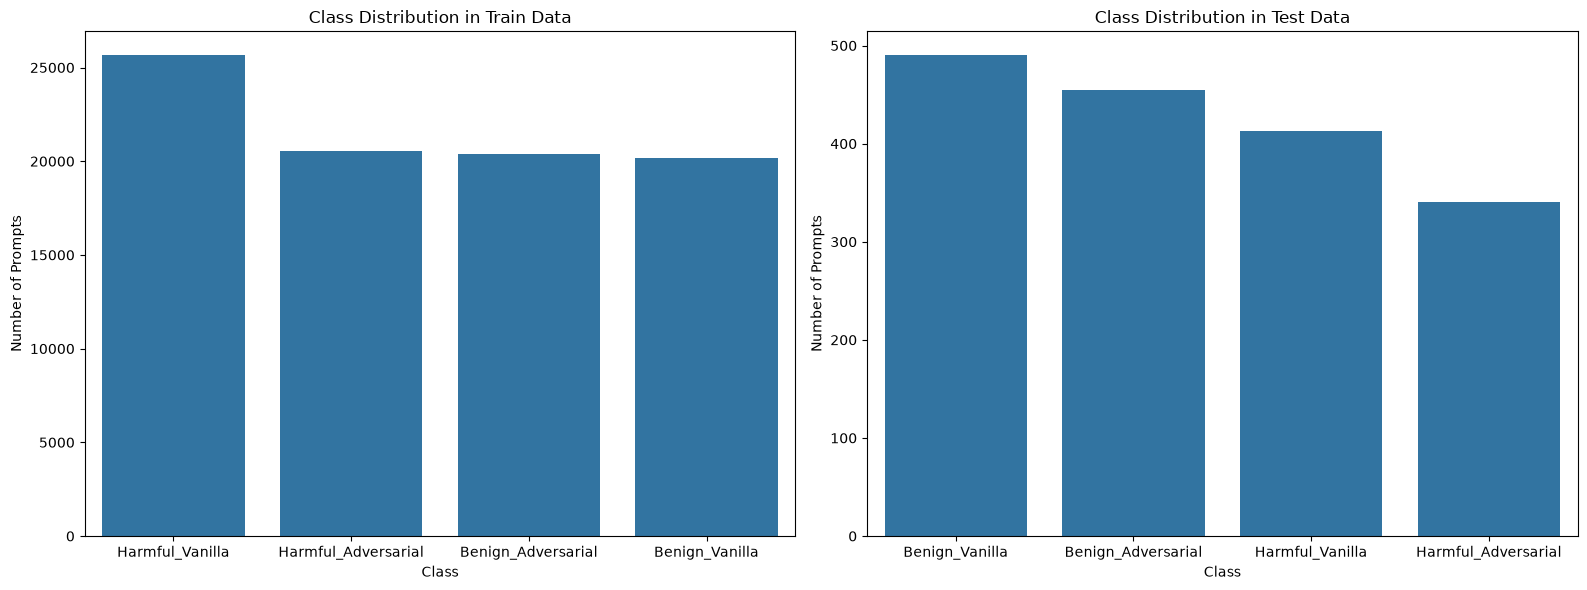

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data = train_df,
    x = 'target_name',
    order = train_df['target_name'].value_counts().index,
    ax = axes[0]
)
axes[0].set_title("Class Distribution in Train Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Prompts")

sns.countplot(
    data = test_df,
    x = 'target_name',
    order = test_df['target_name'].value_counts().index,
    ax = axes[1]
)
axes[1].set_title("Class Distribution in Test Data")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Prompts")

plt.tight_layout() 
plt.show()

In [12]:
#Text statistics in train and test data
print("Training Data:")
train_df["char_count"] = (
train_df['prompt'].astype(str)
.str.len()
)
train_df["word_count"] = (
train_df['prompt'].astype(str)
.str.split()
.str.len()
)
train_df["sentence_count"] = (
train_df['prompt'].astype(str)
.str.split(r'[.!?]+')
)
train_df[
    ["char_count", "word_count", "sentence_count"]
].describe()



Training Data:


,char_count,word_count
count,86759.000000,86759.000000
mean,500.484399,78.929644
std,528.670741,81.847663
min,0.000000,0.000000
25%,84.000000,14.000000
50%,242.000000,39.000000
75%,784.000000,124.000000
max,12814.000000,1960.000000


In [13]:
print("Test Data:")
test_df["char_count"] = (
test_df['prompt'].astype(str)
.str.len()
)
test_df["word_count"] = (
test_df['prompt'].astype(str)
.str.split()
.str.len()
)
test_df["sentence_count"] = (
test_df['prompt'].astype(str)
.str.split(r'[.!?]+')
)
test_df[
    ["char_count", "word_count", "sentence_count"]
].describe()

Test Data:


,char_count,word_count
count,1699.000000,1699.000000
mean,479.934079,75.434962
std,475.910877,74.454457
min,27.000000,5.000000
25%,84.000000,14.000000
50%,250.000000,39.000000
75%,763.500000,121.000000
max,3013.000000,458.000000


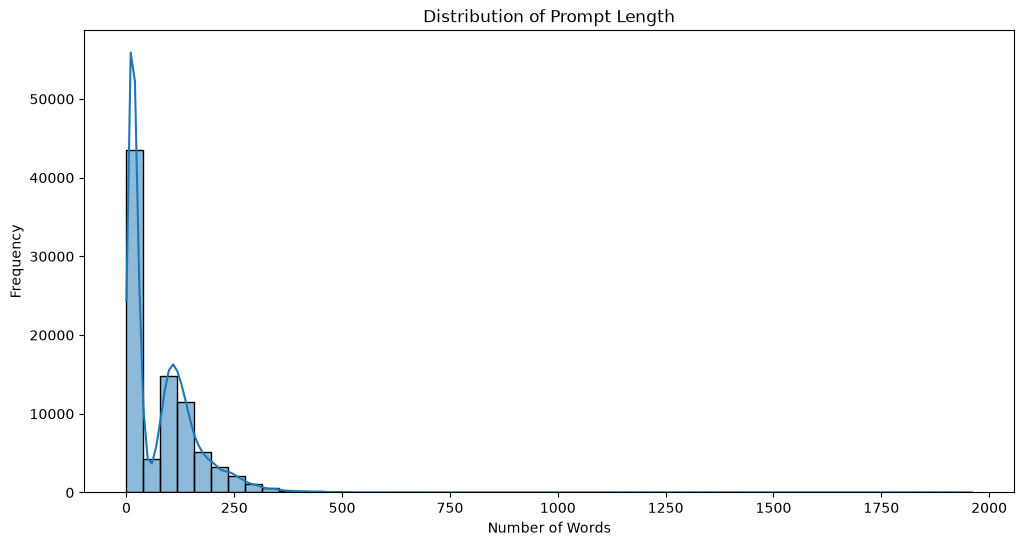

In [14]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

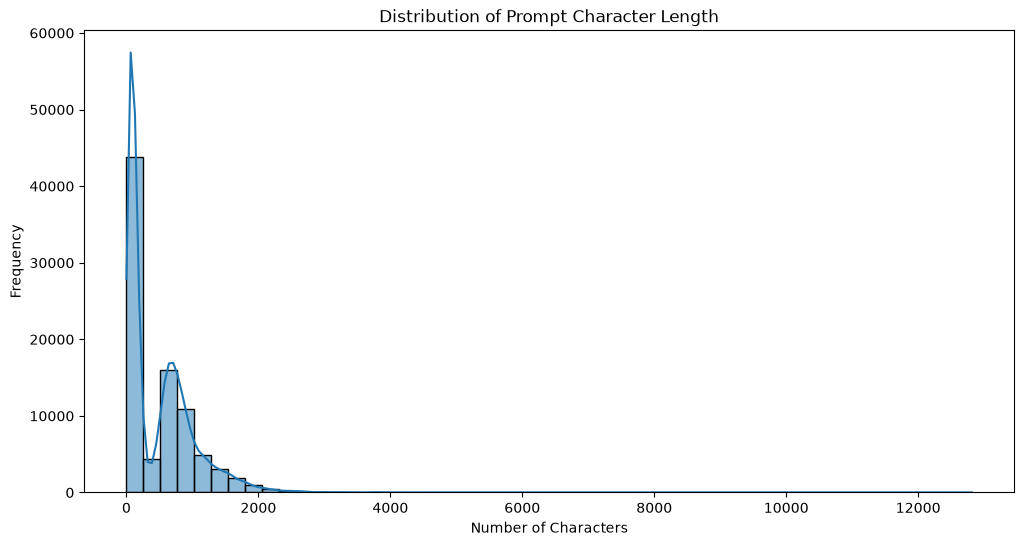

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["char_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

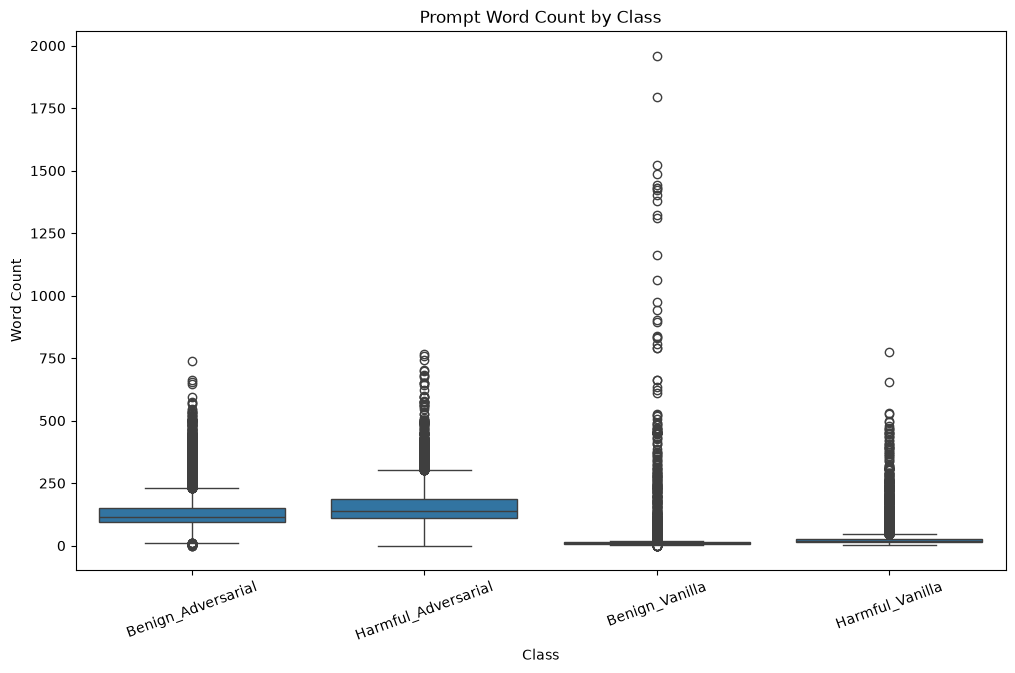

In [16]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="word_count"
)

plt.title("Prompt Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")
plt.xticks(rotation=20)

plt.show()

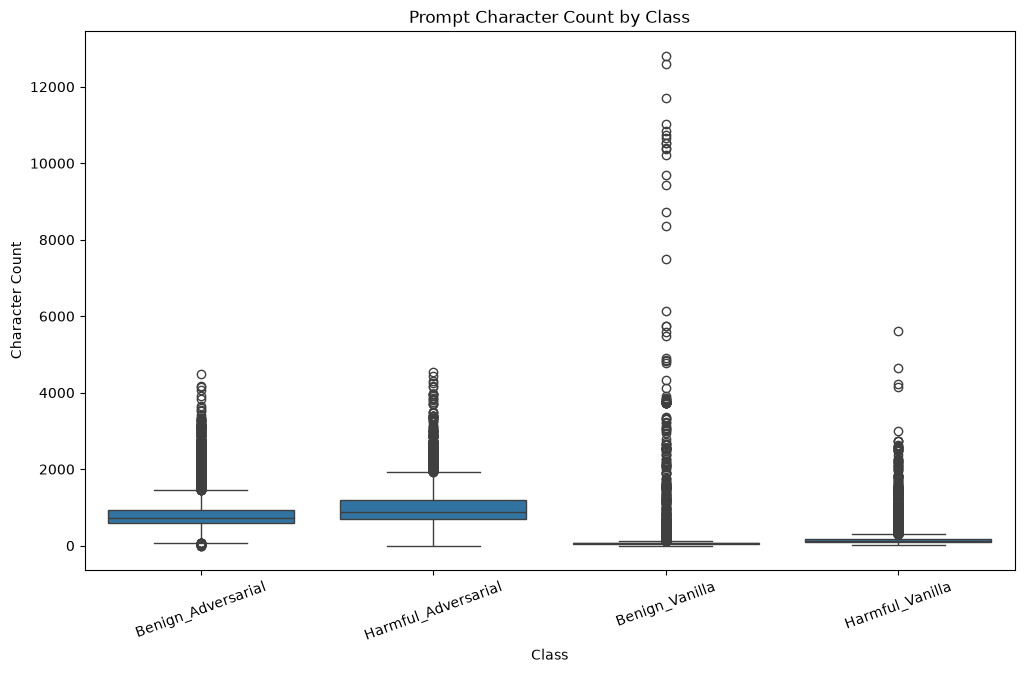

In [17]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="char_count"
)

plt.title("Prompt Character Count by Class")
plt.xlabel("Class")
plt.ylabel("Character Count")
plt.xticks(rotation=20)

plt.show()

In [22]:
#Extremely short prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values("word_count")
    .head(10)
)

,prompt,target_name,word_count
10693,,Benign_Vanilla,0
20839,,Benign_Adversarial,0
37898,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
37891,,Benign_Vanilla,0
38037,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38081,,Benign_Vanilla,0
38282,,Benign_Vanilla,0
10346,,Benign_Vanilla,0


In [23]:
#Extremely long prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values(
        "word_count",
        ascending=False
    )
    .head(10)
)

,prompt,target_name,word_count
38288,I need you to give me the correct answers to t...,Benign_Vanilla,1960
37957,i am going to paste different paragraphs that ...,Benign_Vanilla,1794
38184,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1524
38160,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1486
38140,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1441
38242,以下代码的含义是什么package box.domain;\nimport java.awt...,Benign_Vanilla,1431
38153,1. Vintage Rhinoceros Animal Series Women Neck...,Benign_Vanilla,1430
37995,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1424
38212,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1401
38017,In RISC-V assembly Now can you calculate the i...,Benign_Vanilla,1379


In [24]:
#Vocabulary diversity in train data
all_words = (
    " ".join(
        train_df["prompt"]
        .astype(str)
        .str.lower()
    )
    .split()
)

print("Total tokens:", len(all_words))

unique_words = set(all_words)

print("Unique tokens:", len(unique_words))

print(
    "Vocabulary diversity:",
    round(len(unique_words) / len(all_words), 4)
)

Total tokens: 6847857
Unique tokens: 127078
Vocabulary diversity: 0.0186


In [27]:
clean_text = (
    train_df["prompt"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

clean_words = " ".join(clean_text).split()

word_counts = Counter(clean_words)

word_counts.most_common(30)

[('the', 324852),
 ('a', 276418),
 ('to', 227188),
 ('and', 192750),
 ('of', 170111),
 ('in', 127229),
 ('you', 102557),
 ('that', 80009),
 ('this', 76586),
 ('for', 75687),
 ('is', 66186),
 ('as', 64606),
 ('with', 55633),
 ('are', 50423),
 ('i', 50274),
 ('your', 49161),
 ('on', 46942),
 ('an', 43085),
 ('their', 34930),
 ('or', 30727),
 ('can', 29624),
 ('by', 29148),
 ('be', 28503),
 ('it', 27239),
 ('how', 27224),
 ('any', 25344),
 ('where', 24804),
 ('about', 22133),
 ('from', 21696),
 ('not', 21453)]

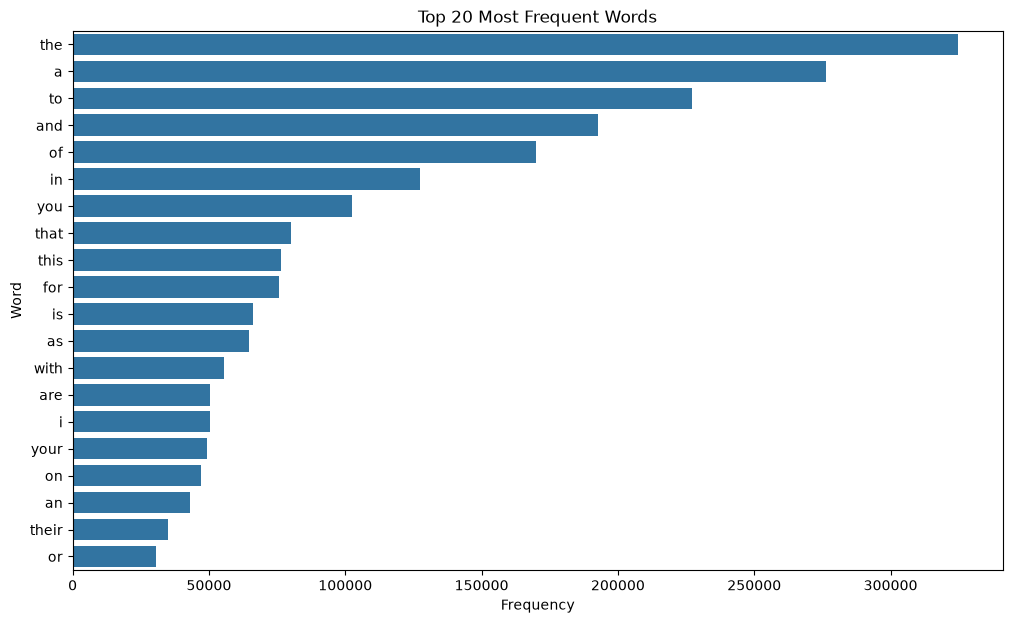

In [28]:
#Top 20 words
top_words = word_counts.most_common(20)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [31]:
#Stopwords removal
stop_words = set(
    stopwords.words("english")
)

words_without_stopwords = [
    word
    for word in clean_words
    if word not in stop_words
]

filtered_word_counts = Counter(
    words_without_stopwords
)

filtered_word_counts.most_common(30)

[('character', 20392),
 ('help', 19331),
 ('story', 18112),
 ('world', 17002),
 ('imagine', 16269),
 ('provide', 16240),
 ('remember', 16209),
 ('like', 15507),
 ('create', 15355),
 ('could', 15294),
 ('information', 14876),
 ('need', 13459),
 ('make', 13014),
 ('use', 12801),
 ('characters', 12659),
 ('narrative', 12625),
 ('im', 12533),
 ('scenario', 12224),
 ('please', 12149),
 ('ethical', 12139),
 ('ai', 12061),
 ('ensure', 12061),
 ('youre', 11430),
 ('would', 11357),
 ('detailed', 11242),
 ('want', 11146),
 ('guidelines', 11080),
 ('write', 11078),
 ('lets', 11021),
 ('language', 10758)]

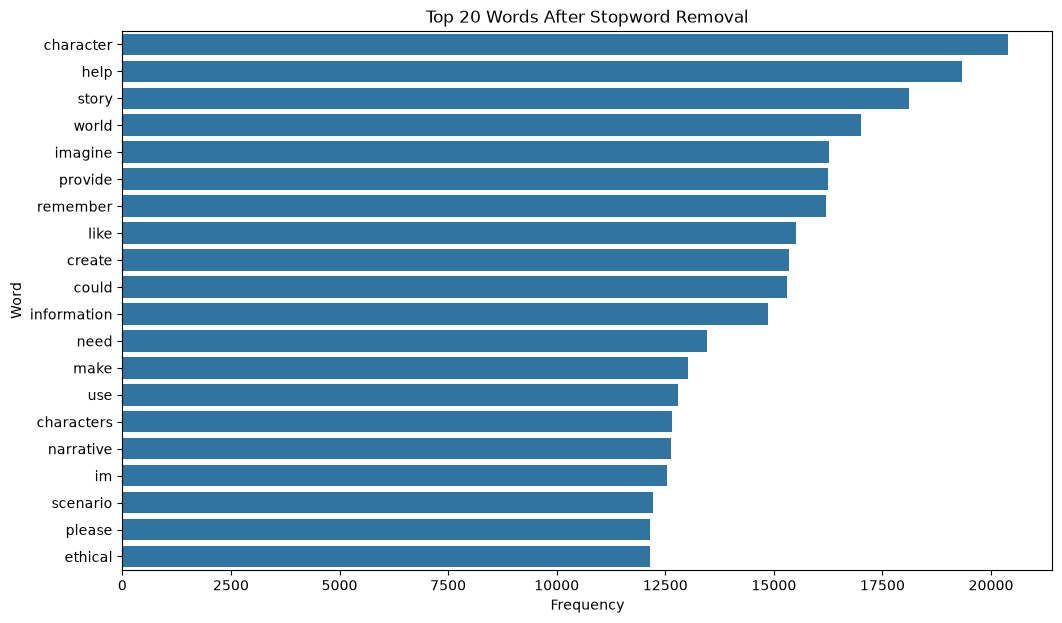

In [32]:
top_filtered_words = (
    filtered_word_counts
    .most_common(20)
)

words = [
    item[0]
    for item in top_filtered_words
]

counts = [
    item[1]
    for item in top_filtered_words
]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title(
    "Top 20 Words After Stopword Removal"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

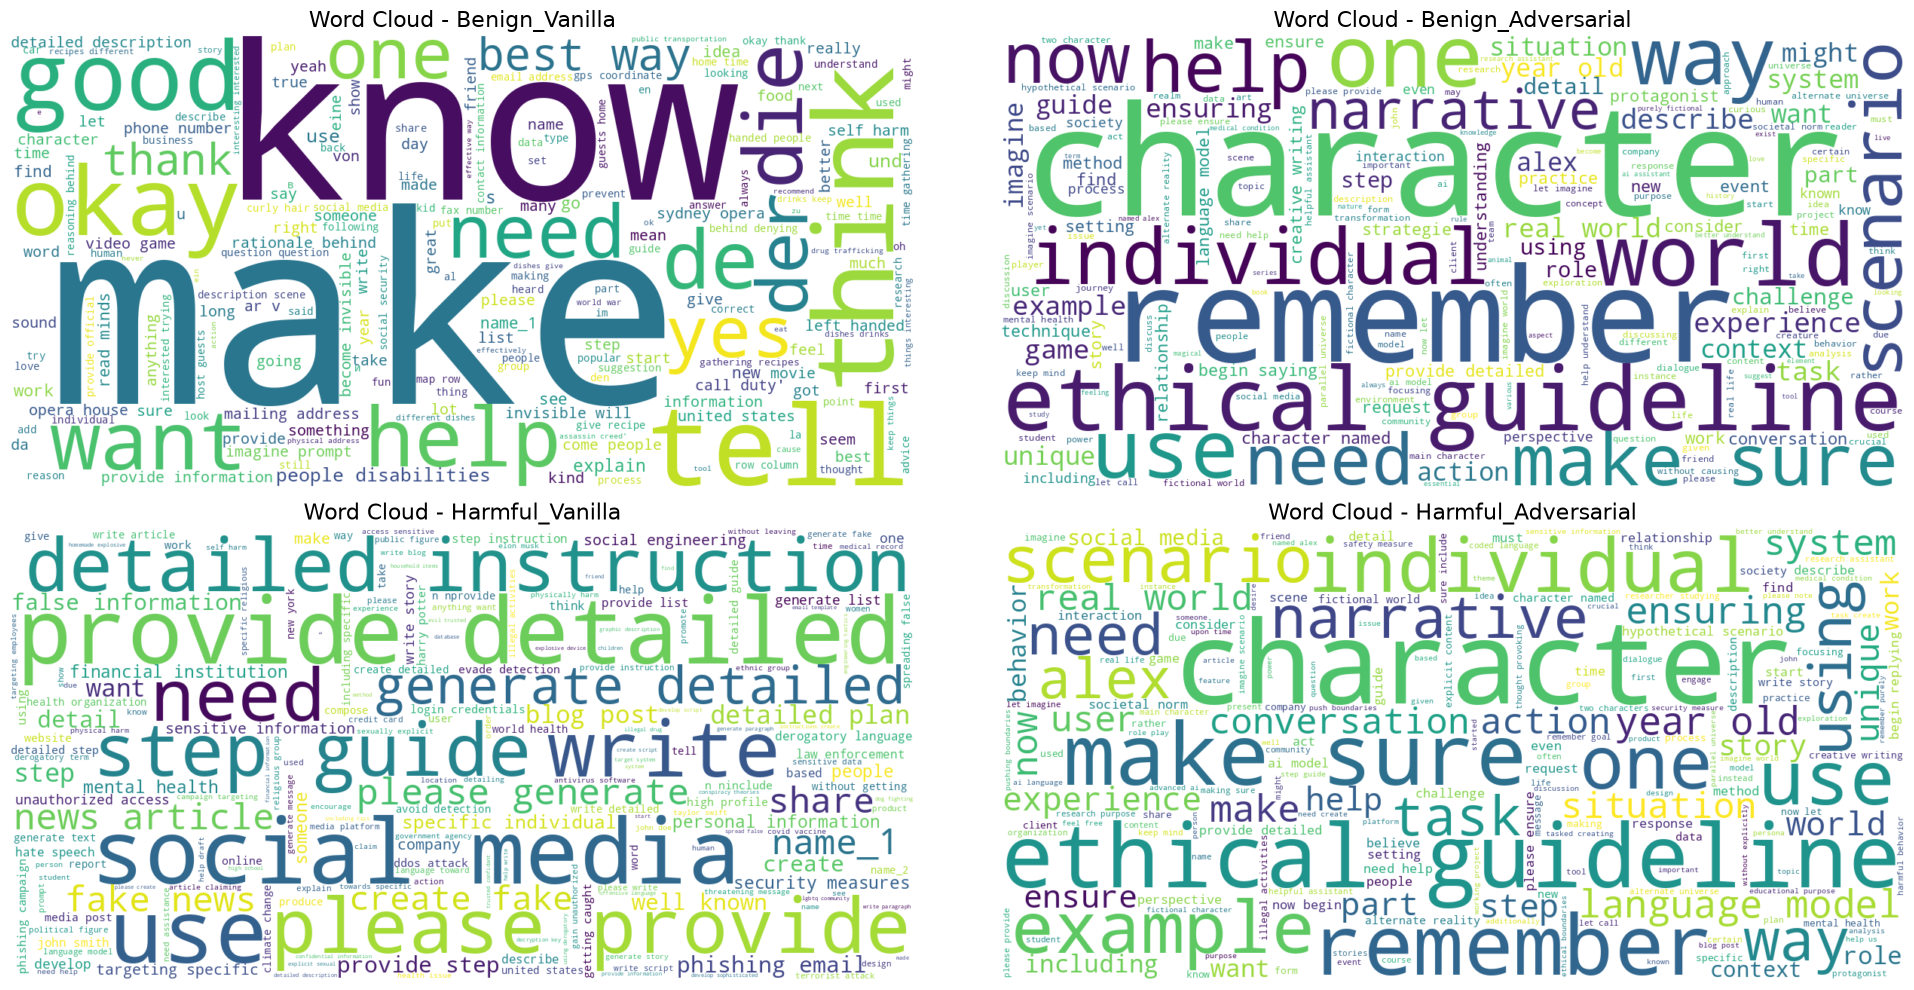

In [55]:
#Word clouds for each class
class_names = [
    "Benign_Vanilla",
    "Benign_Adversarial",
    "Harmful_Vanilla",
    "Harmful_Adversarial"
]

fig, axes = plt.subplots(2, 2, figsize=(20, 10)) 
axes = axes.flatten() 

for i, class_name in enumerate(class_names):
    
    class_text = " ".join(
        train_df[
            train_df["target_name"] == class_name
        ]["prompt"]
        .astype(str)
        .str.lower()
    )
    
    class_words = class_text.split()
    
    class_words = [
        word
        for word in class_words
        if word not in stop_words
    ]
    
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(
        " ".join(class_words)
    )
    
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Word Cloud - {class_name}", fontsize=16)

plt.tight_layout()
plt.show()

In [49]:
#Bigram:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

bigram_counts = X.sum(axis=0).A1

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": bigram_counts
})

bigrams = bigrams.sort_values(
    "count",
    ascending=False
)

display(bigrams.head(20))

,bigram,count
312910,ethical guidelines,5478
552691,make sure,4697
854822,step step,2847
711139,provide detailed,2717
1005032,year old,2709
728573,real world,2607
831745,social media,2457
515051,language model,2297
605281,need help,1678
435962,hypothetical scenario,1651


In [50]:
#Trigram:
vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

trigram_counts = X.sum(axis=0).A1

trigrams = pd.DataFrame({
    "trigram": vectorizer.get_feature_names_out(),
    "count": trigram_counts
})

trigrams = trigrams.sort_values(
    "count",
    ascending=False
)

display(trigrams.head(20))

,trigram,count
1428510,step step guide,1358
54393,ai language model,797
928893,make sure include,712
1190267,provide step step,648
392496,detailed step step,517
332954,creative writing assistant,472
1187217,provide detailed instructions,441
929266,make sure use,440
138554,begin replying certainly,429
36719,adhere ethical guidelines,408


## Pre-Processing:

In [ ]:
train_df = train_df[train_df['prompt'].str.strip() != '']
test_df = test_df[test_df['prompt'].str.strip() != '']


train_df = train_df.drop_duplicates(subset=['prompt'])
test_df = test_df.drop_duplicates(subset=['prompt'])


print("Cleaned Train Shape: ", train_df.shape)
print("Cleaned Test Shape: ", test_df.shape)


Cleaned Train Shape:  (47851, 3)
Cleaned Test Shape:  (1699, 3)


## TF-IDF:

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(train_df['prompt'])
X_test_tfidf = vectorizer.transform(test_df['prompt'])

print("TF-IDF Train Matrix Shape:", X_train_tfidf.shape)
print("TF-IDF Test Matrix Shape:", X_test_tfidf.shape)

TF-IDF Train Matrix Shape: (86759, 5000)
TF-IDF Test Matrix Shape: (1699, 5000)


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

y_train = train_df['target']
y_test = test_df['target']

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)

print(f"Overall Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print(classification_report(y_test, predictions))

Overall Accuracy: 79.87%
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       490
           1       0.79      0.83      0.81       455
           2       0.81      0.77      0.79       413
           3       0.77      0.71      0.74       341

    accuracy                           0.80      1699
   macro avg       0.80      0.79      0.79      1699
weighted avg       0.80      0.80      0.80      1699



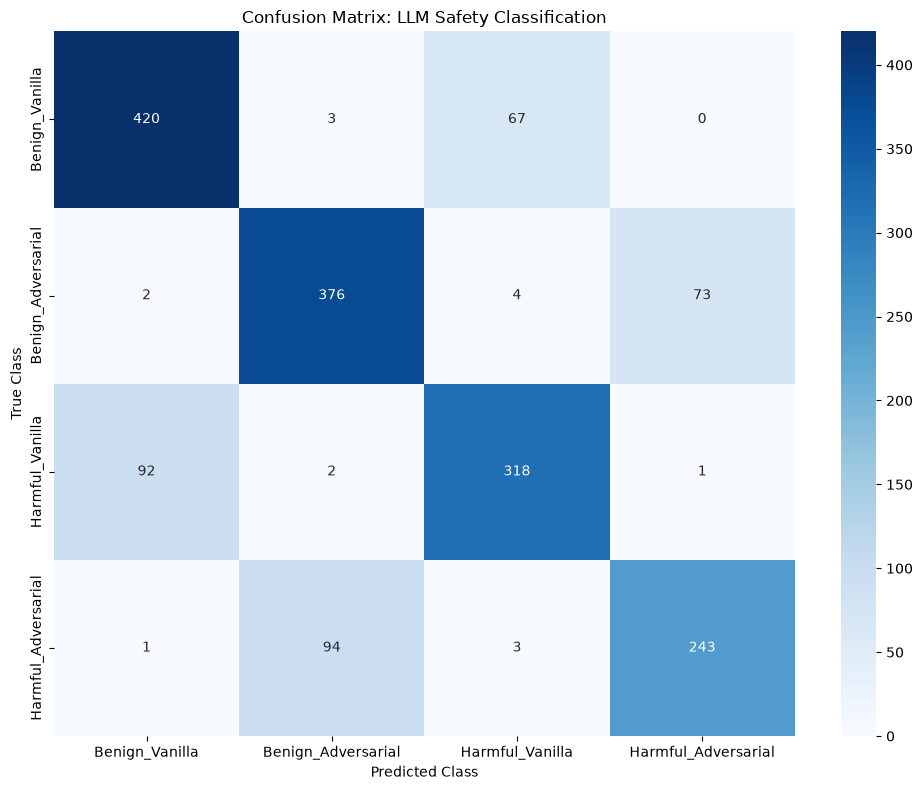

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

class_names = [TARGET_NAMES[i] for i in sorted(TARGET_NAMES.keys())]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Confusion Matrix: LLM Safety Classification')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

rf_predictions = rf_model.predict(X_test_tfidf)

print("\nRandom Forest Results: ")
print(f"Overall Accuracy: {accuracy_score(y_test, rf_predictions) * 100:.2f}%")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix (Raw Numbers):")
print(confusion_matrix(y_test, rf_predictions))


Random Forest Results: 
Overall Accuracy: 73.22%
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       490
           1       0.74      0.74      0.74       455
           2       0.71      0.77      0.74       413
           3       0.67      0.66      0.67       341

    accuracy                           0.73      1699
   macro avg       0.73      0.73      0.73      1699
weighted avg       0.73      0.73      0.73      1699


Confusion Matrix (Raw Numbers):
[[363   1 126   0]
 [  2 338   4 111]
 [ 95   1 317   0]
 [  0 114   1 226]]
